<h1><strong>Customer Churn</strong></h1>

In [1445]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Suppressing warnings
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.cluster import KMeans
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.exceptions import NotFittedError


import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import l2

In [1446]:
import matplotlib.pyplot as plt
import seaborn as sns

# General Style Settings
sns.set_style("whitegrid")  # Light grid background
sns.set_palette("viridis")  # Color palette
plt.rcParams["figure.figsize"] = (8, 4)  # Default figure size
plt.rcParams["axes.labelsize"] = 12  # Axis label size
plt.rcParams["axes.titlesize"] = 14  # Title size
plt.rcParams["xtick.labelsize"] = 11  # X-axis tick label size
plt.rcParams["ytick.labelsize"] = 11  # Y-axis tick label size
plt.rcParams["legend.fontsize"] = 11  # Legend font size
plt.rcParams["axes.edgecolor"] = "black"  # Border color of the plot
plt.rcParams["grid.alpha"] = 0.5  # Grid line transparency


def customize_plot(title="", xlabel="", ylabel=""):
    """
    Customizes the plot by adding a title, x-axis label, y-axis label,
    and setting grid and rotation properties.
    """
    plt.title(title, fontsize=14, fontweight="bold", color="darkblue")  # Set title
    plt.xlabel(xlabel, fontsize=12, fontweight="bold")  # Set x-axis label
    plt.ylabel(ylabel, fontsize=12, fontweight="bold")  # Set y-axis label
    plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
    plt.grid(True, linestyle="--", alpha=0.6)  # Add dashed grid lines




In [1447]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [1448]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#### <span> Understanding the Data</span>


In [1449]:
df.sample(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
4868,2568-OIADY,Female,0,Yes,No,37,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.50,3762,Yes
4948,3446-QDSZF,Female,0,No,No,4,Yes,No,DSL,No,No,No,No,Yes,No,Month-to-month,No,Credit card (automatic),55.50,227.35,No
5890,0383-CLDDA,Female,0,No,No,69,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),85.35,5897.4,No
3867,4922-CVPDX,Female,0,Yes,No,26,Yes,No,DSL,No,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),73.50,1905.7,No
4921,0089-IIQKO,Female,0,Yes,Yes,39,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,Month-to-month,Yes,Credit card (automatic),99.95,3767.4,No
5220,2282-YGNOR,Female,0,No,No,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Credit card (automatic),58.00,1734.5,No
5590,0487-VVUVK,Male,0,Yes,Yes,25,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,19.15,477.6,No
4969,2303-PJYHN,Female,0,Yes,No,2,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),19.85,52,No
6842,5546-QUERU,Male,0,No,No,13,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.95,257,No
2033,8305-VHZBZ,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.20,20.2,Yes


In [1450]:
df.shape

(7043, 21)

In [1451]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [1452]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [1453]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [1454]:
df = df.dropna()
df.shape

(7043, 21)

In [1455]:
df.duplicated().sum()

0

#### <span>Data Manipulation</span>


In [1456]:
df = df.drop("customerID", axis=1)

In [1457]:
df[df["TotalCharges"] == ' ']

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [1458]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [1459]:
df[df["TotalCharges"] == ' ']


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [1460]:
df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [1461]:
df['TotalCharges'] = df['TotalCharges'].replace([np.inf, -np.inf], np.nan)  
df = df.dropna(subset=['TotalCharges'])  


In [1462]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [1463]:
def detect_outliers(dataframe):
    numeric_columns = dataframe.select_dtypes(include='number').columns

    for column in numeric_columns:
        q1 = dataframe[column].quantile(0.25)
        q3 = dataframe[column].quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outlier_rows = dataframe[(dataframe[column] < lower_bound) | (dataframe[column] > upper_bound)]

        print(f"{column} - Outliers:")
        print(f"Number of Outliers: {len(outlier_rows)}")
        print(outlier_rows[[column]])
        print("-" * 30)

In [1464]:
outliers(df)

SeniorCitizen - Outliers:
Number of Outliers: 1142
      SeniorCitizen
20                1
30                1
31                1
34                1
50                1
...             ...
7023              1
7029              1
7031              1
7032              1
7041              1

[1142 rows x 1 columns]
---------------------------
tenure - Outliers:
Number of Outliers: 0
Empty DataFrame
Columns: [tenure]
Index: []
---------------------------
MonthlyCharges - Outliers:
Number of Outliers: 0
Empty DataFrame
Columns: [MonthlyCharges]
Index: []
---------------------------
TotalCharges - Outliers:
Number of Outliers: 0
Empty DataFrame
Columns: [TotalCharges]
Index: []
---------------------------


In [1465]:
df[df["tenure"] == 0]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [1466]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


#### <span> Data Visualization</span>

In [1467]:
def plot_numeric_distributions(df):

    numeric_cols = df.select_dtypes(include=['number']).columns

    num_cols = len(numeric_cols)
    num_rows = (num_cols // 3) + 1

    plt.figure(figsize=(15, 5 * num_rows))

    for i, col in enumerate(numeric_cols, 1):
        plt.subplot(num_rows, 3, i)
        sns.histplot(df[col], kde=True, color='blue', bins=30)
        plt.title(f'Distribution of {col}', fontsize=12)
        plt.xlabel(col)
        plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()


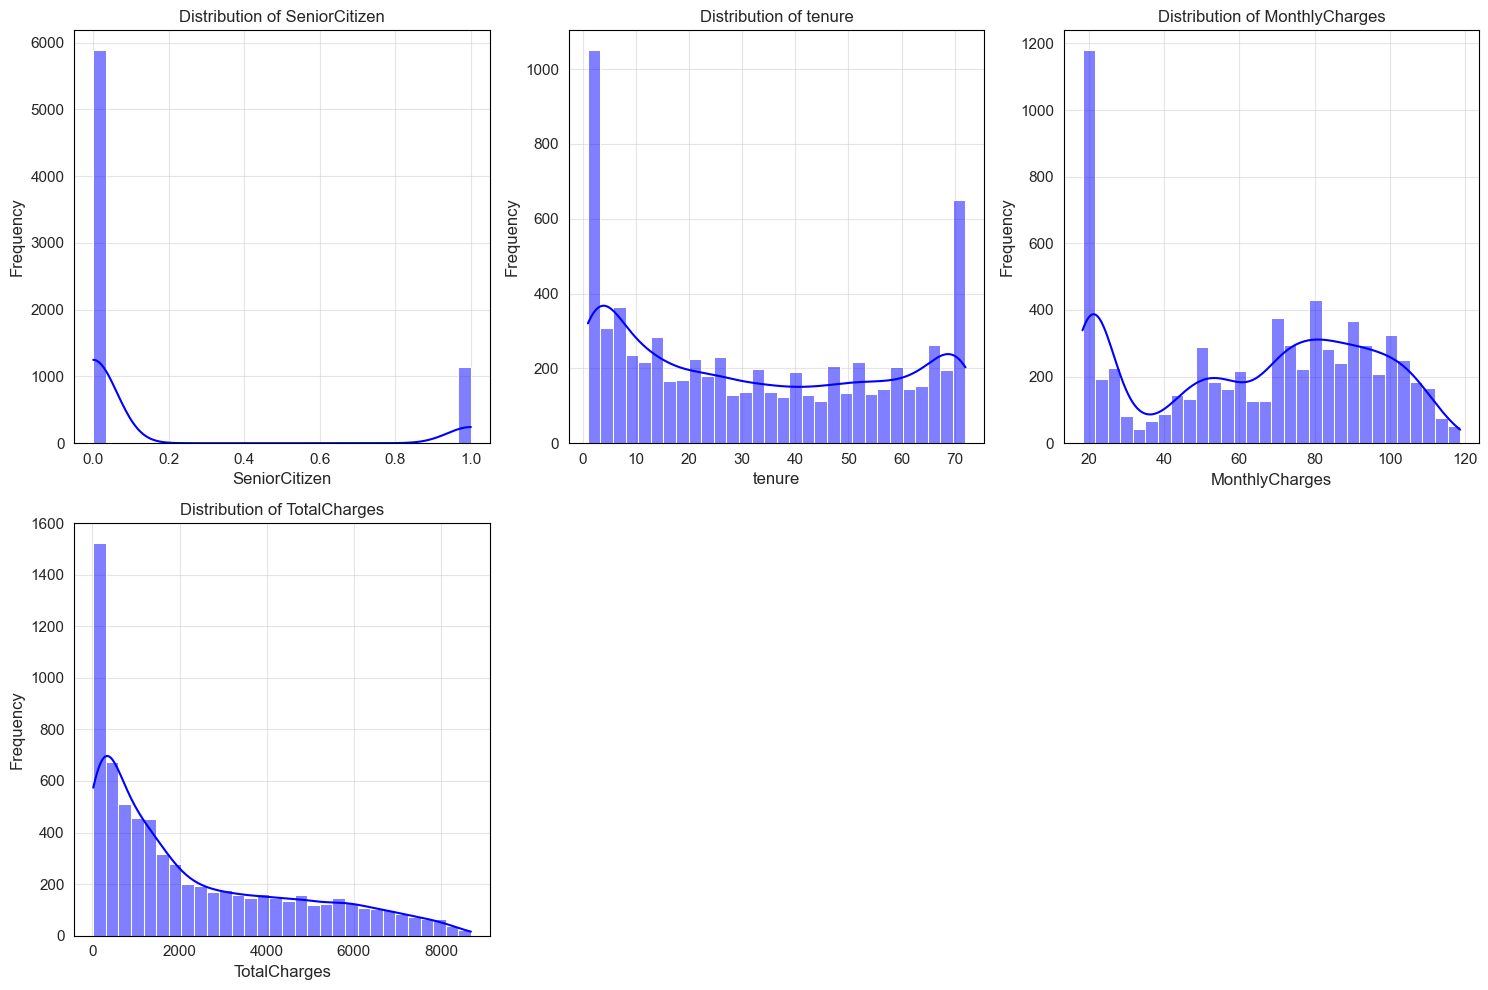

In [1468]:
plot_numeric_distributions(df)

In [1469]:
def plot_categorical_barcharts(df, max_unique=30):
    categorical_columns = [
        col for col in df.select_dtypes(include=['object', 'category']).columns
        if df[col].nunique() < max_unique
    ]

    num_columns = len(categorical_columns)

    if num_columns == 0:
        print(f"No categorical columns with less than {max_unique} unique values.")
        return

    num_rows = math.ceil(num_columns / 3)
    num_cols = min(3, num_columns)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 5))
    axes = axes.flatten()

    for i, col in enumerate(categorical_columns):
        df[col].value_counts().plot.bar(
            ax=axes[i],
            color='lightblue',
            edgecolor='black'
        )
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_ylabel('Count')
        axes[i].set_xlabel('Categories')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

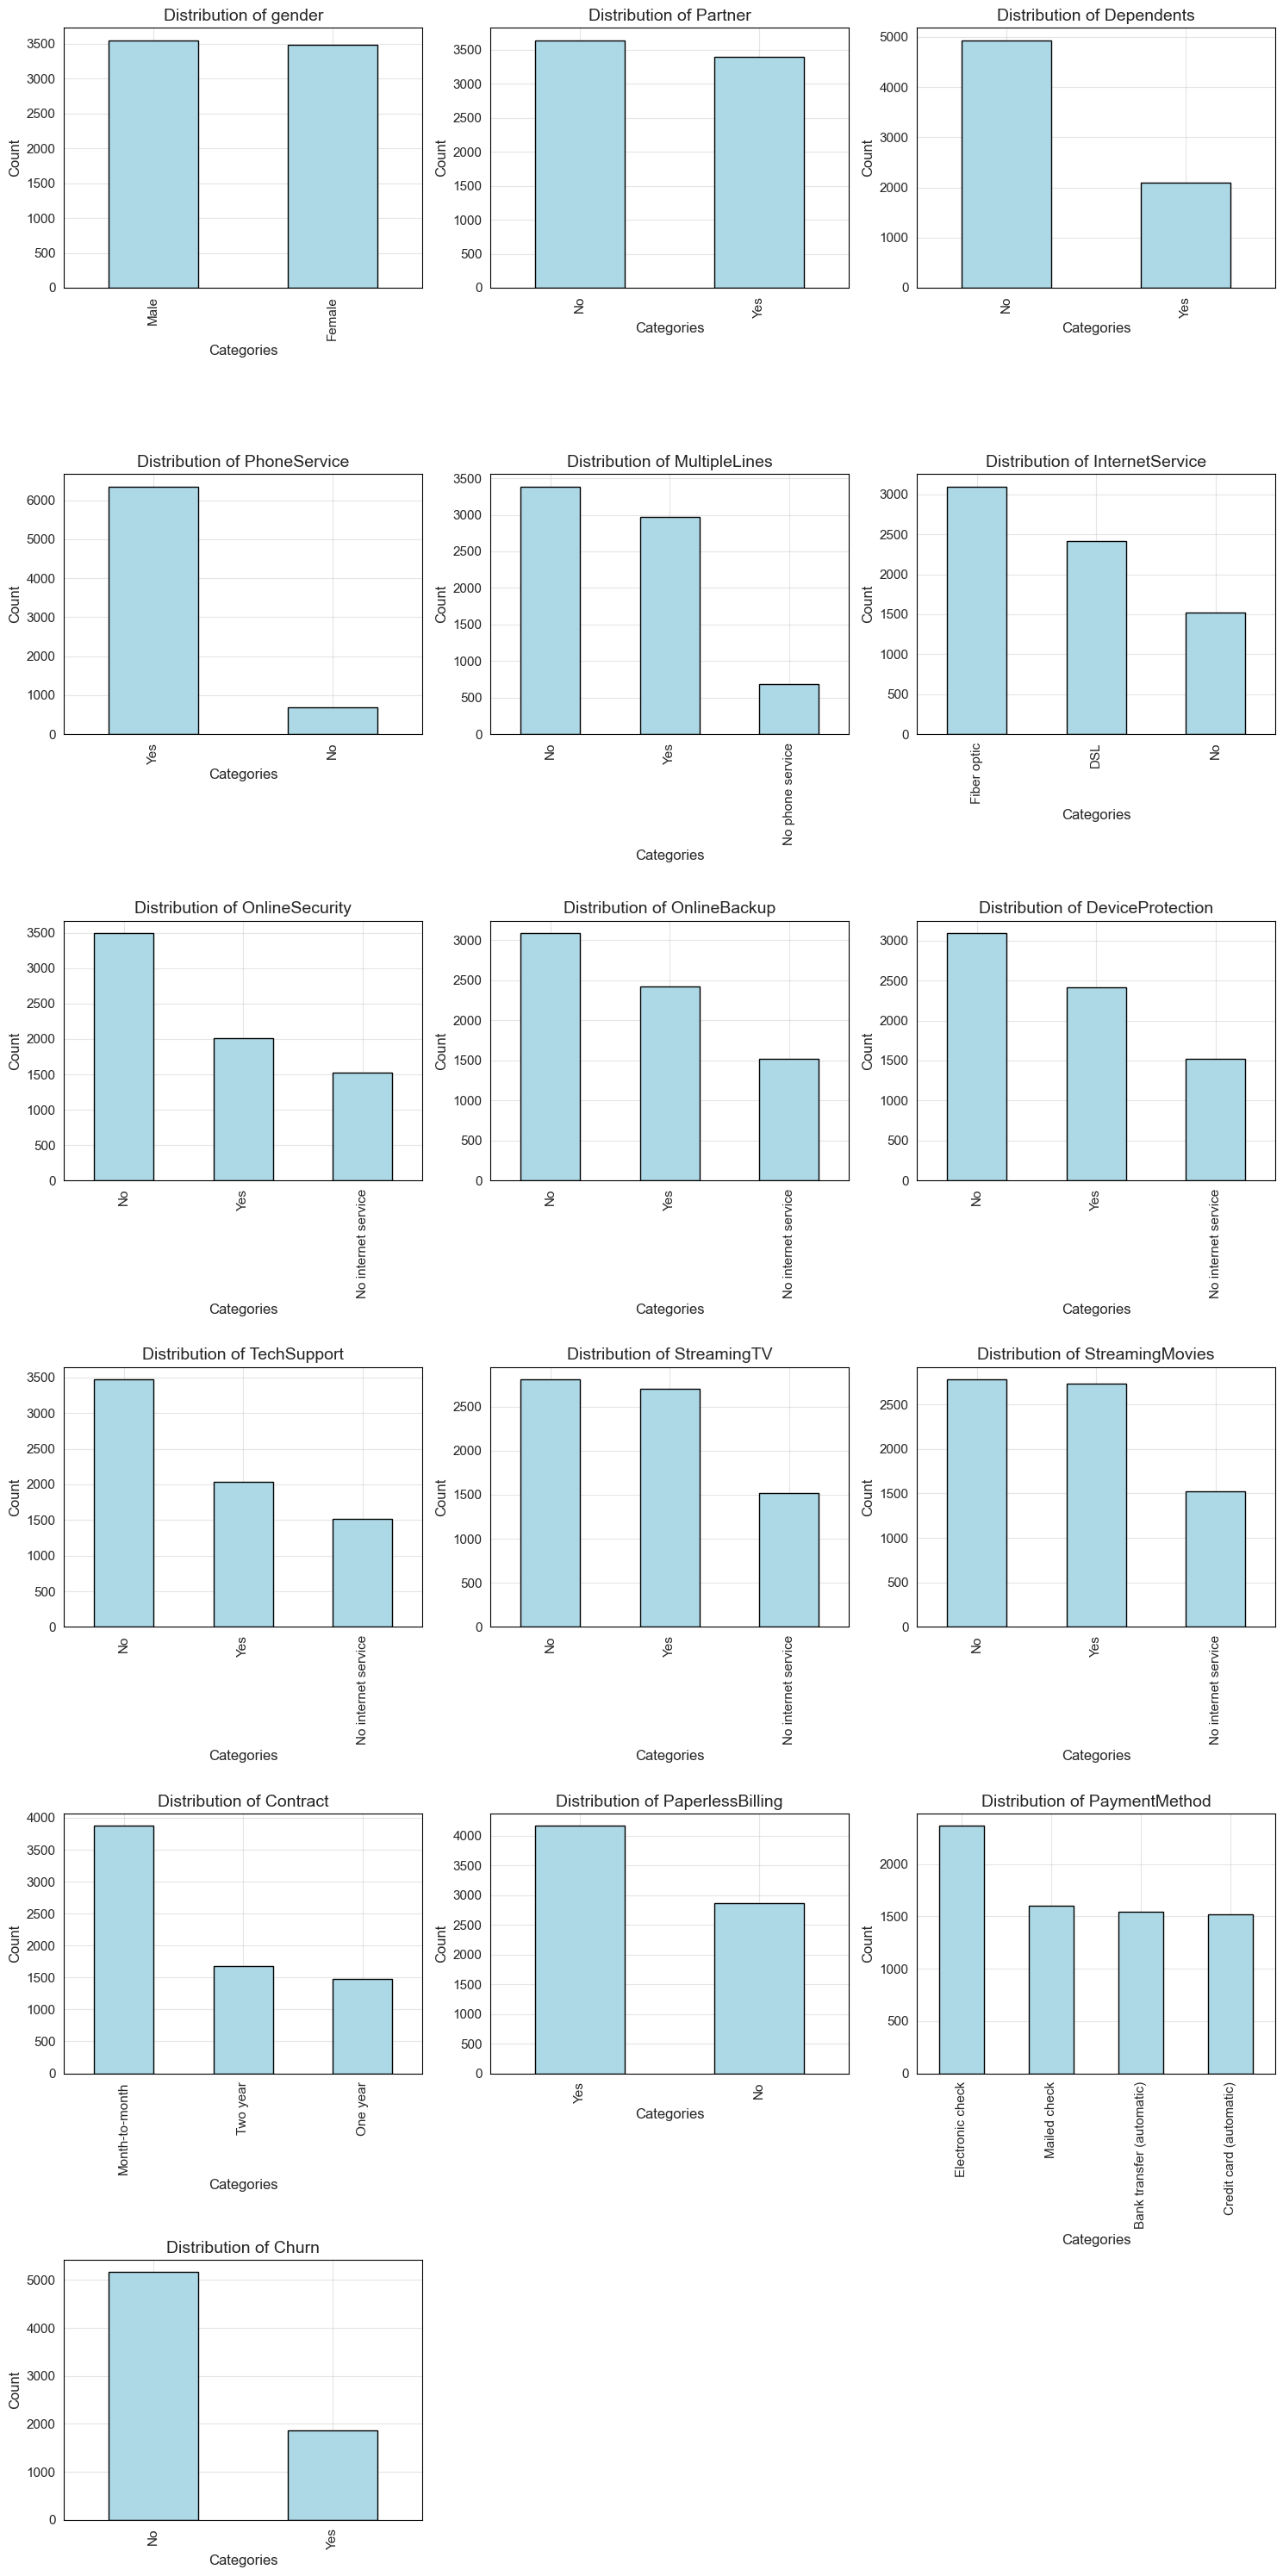

In [1470]:
plot_categorical_barcharts(df, max_unique=30)

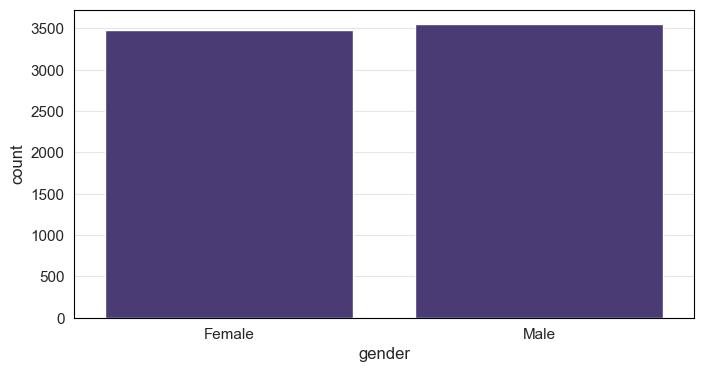

In [1471]:
sns.countplot(x='gender', data=df)
plt.show()

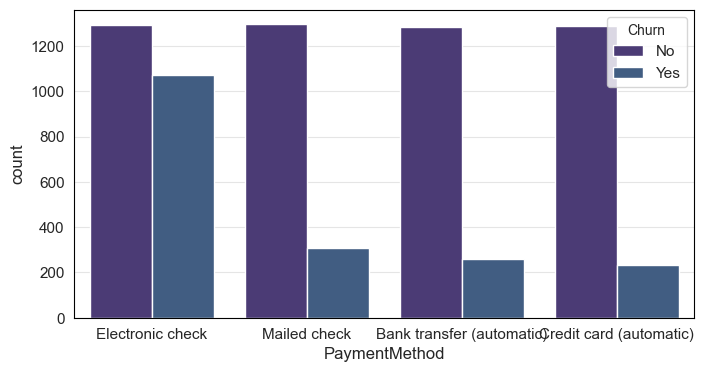

In [1472]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.show()

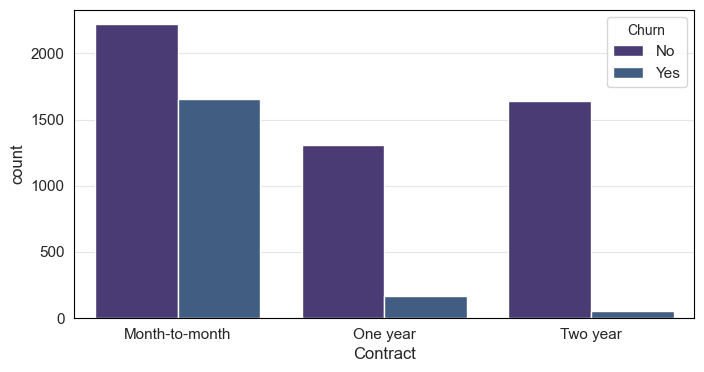

In [1473]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.show()

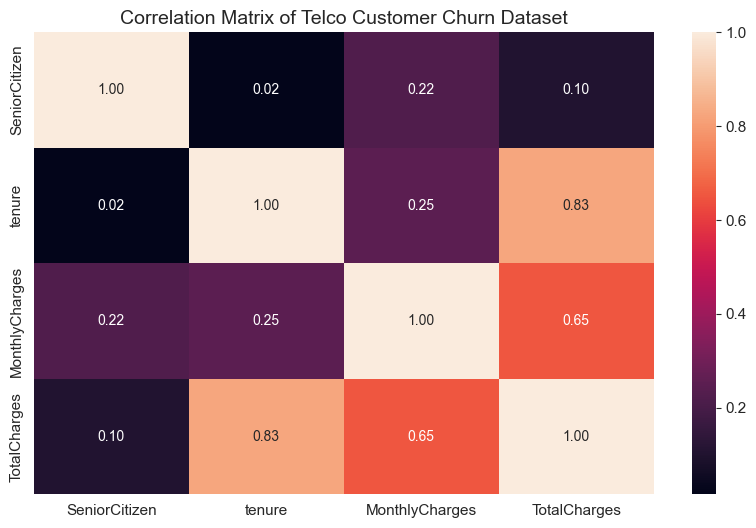

In [1474]:
fig, ax = plt.subplots(figsize=(10, 6))
correlation_matrix = df.select_dtypes(include='number').corr()
sns.heatmap(data=correlation_matrix, annot=True, fmt=".2f", ax=ax)
ax.set_title("Correlation Matrix of Telco Customer Churn Dataset")
plt.show()


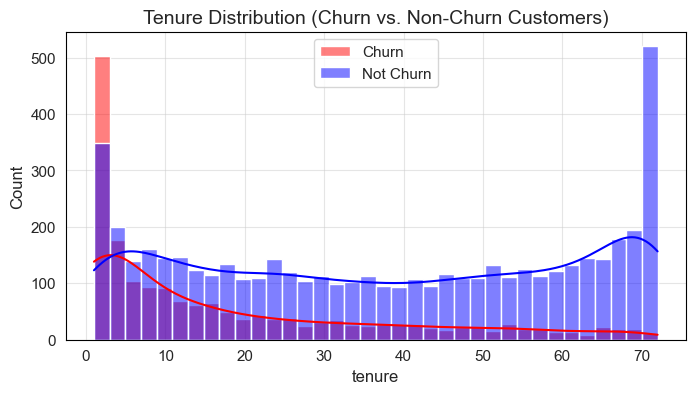

In [1475]:

sns.histplot(df[df['Churn'] == 'Yes']['tenure'], color="red", label="Churn", kde=True, binwidth=2)
sns.histplot(df[df['Churn'] == 'No']['tenure'], color="blue", label="Not Churn", kde=True, binwidth=2)

plt.legend()
plt.title("Tenure Distribution (Churn vs. Non-Churn Customers)")

plt.show()


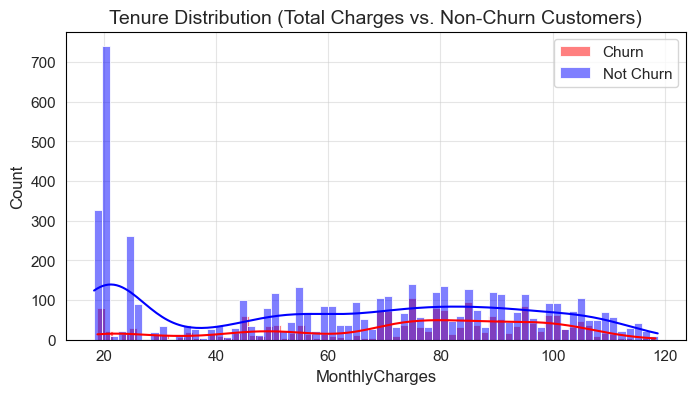

In [1476]:

sns.histplot(df[df['Churn'] == 'Yes']['MonthlyCharges'], color="red", label="Churn", kde=True, bins=70)
sns.histplot(df[df['Churn'] == 'No']['MonthlyCharges'], color="blue", label="Not Churn", kde=True, bins=70)

plt.legend()
plt.title("Tenure Distribution (Total Charges vs. Non-Churn Customers)")

plt.show()


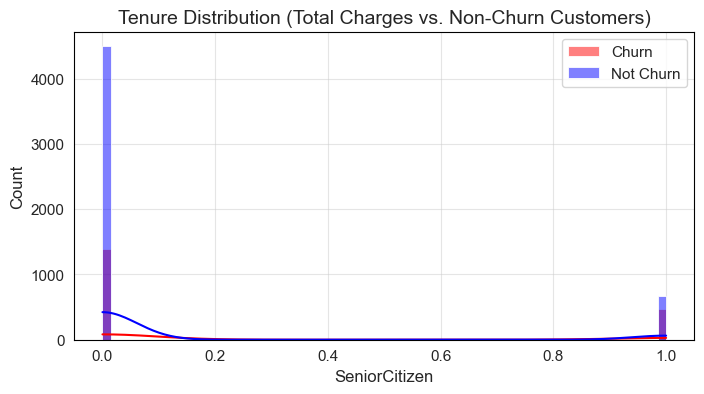

In [1477]:
sns.histplot(df[df['Churn'] == 'Yes']['SeniorCitizen'], color="red", label="Churn", kde=True, bins=70)
sns.histplot(df[df['Churn'] == 'No']['SeniorCitizen'], color="blue", label="Not Churn", kde=True, bins=70)

plt.legend()
plt.title("Tenure Distribution (Total Charges vs. Non-Churn Customers)")

plt.show()

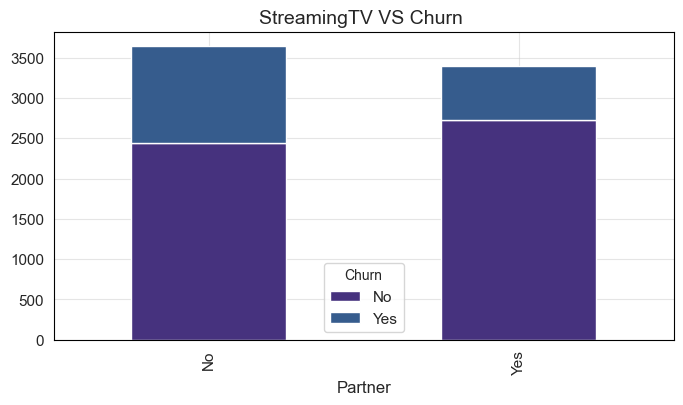

In [1478]:
pd.crosstab(df['Partner'], df['Churn']).plot(kind='bar', stacked=True)
plt.title("StreamingTV VS Churn ")
plt.show()


In [1479]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

#### <span> Data Preprocessing</span>

In [1480]:
df.Churn = df.Churn.map({'Yes': 1, 'No': 0})

In [1481]:
X = df[['Contract', 'InternetService', 'PaymentMethod', 'TotalCharges', 'tenure', 'OnlineSecurity', 'StreamingTV', 'PaperlessBilling', 'StreamingMovies', 'MultipleLines']]
y = df.Churn

In [1482]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20,stratify=y, random_state=42)

In [1483]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [1484]:
# Define columns for different encoding strategies
binary_cols = ['PaperlessBilling']
ordinal_cols = ['Contract', 'InternetService']
nominal_cols = ['MultipleLines', 'OnlineSecurity', 'StreamingTV', 'StreamingMovies', 'PaymentMethod']
numeric_cols = ['TotalCharges', 'tenure']

# Define ordinal categories for ordered encoding
ordinal_mapping = [['Month-to-month', 'One year', 'Two year'],
                   ['No', 'DSL', 'Fiber optic']]

# Define transformers
binary_transformer = OneHotEncoder(drop='if_binary')  # Automatically encodes binary as 0/1
ordinal_transformer = OrdinalEncoder(categories=ordinal_mapping)
nominal_transformer = OneHotEncoder(drop='first')  # Drop first to avoid dummy variable trap
numeric_transformer = StandardScaler()  # Apply StandardScaler to numeric columns

# Apply transformations using ColumnTransformer
preprocessor = ColumnTransformer([
    ('binary', binary_transformer, binary_cols),
    ('ordinal', ordinal_transformer, ordinal_cols),
    ('nominal', nominal_transformer, nominal_cols),
    ('numeric', numeric_transformer, numeric_cols),
], remainder='passthrough')  # Keep any extra columns if needed

In [1485]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [1486]:
pd.DataFrame(X_train_transformed).head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,0.0,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.659900,1.321816
1,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.562252,-0.267410
2,0.0,2.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.756104,1.444064
3,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,-0.908326,-1.204646
4,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,-0.101561,0.669826


In [1487]:
pd.DataFrame(X_train_transformed).isnull().sum()

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
dtype: int64

In [1488]:
def eval_metric(model, X_train, y_train, X_test, y_test):
    plt.figure(figsize=(8, 6))
    y_train_pred = np.array(np.where(model.predict(X_train)>0.5, 1, 0)).reshape((-1,))
    y_pred = np.array(np.where(model.predict(X_test)>0.5, 1, 0)).reshape((-1,))
    print("Train_Set")
    cfm = confusion_matrix(y_train, y_train_pred)
    sns.heatmap(cfm, annot=True, fmt='d', cmap='viridis')
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Train_Set Confusion Matrix")
    plt.show()
    print(classification_report(y_train, y_train_pred))
    eval_dict_train = classification_report(y_train, y_train_pred, output_dict=True)
    print()
    print("Test_Set")
    cfm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cfm, annot=True, fmt='d', cmap='viridis')
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Test_Set Confusion Matrix")
    plt.show()
    eval_dict_test = classification_report(y_test, y_pred, output_dict=True)
    print(classification_report(y_test, y_pred))
    print()
    return eval_dict_train, eval_dict_test

### <span> Modeling</span>

#### <span> Logistic model</span>

In [1489]:
logistic = LogisticRegression(class_weight='balanced', random_state=42)
logistic.fit(X_train_transformed , y_train)

LogisticRegression(class_weight='balanced', random_state=42)

Train_Set


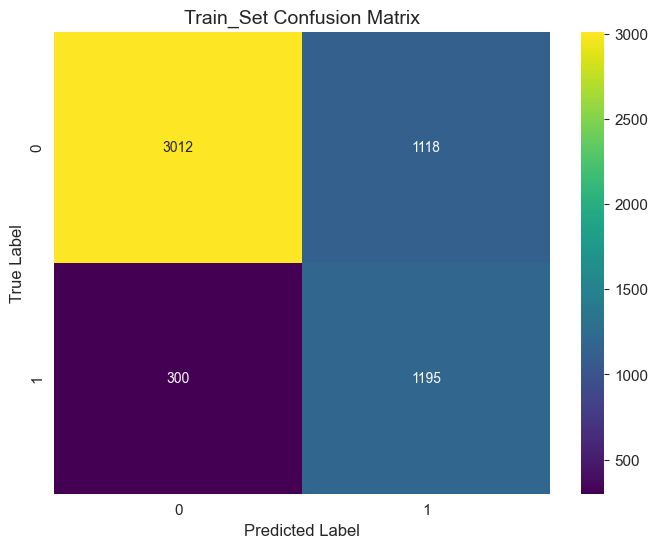

              precision    recall  f1-score   support

           0       0.91      0.73      0.81      4130
           1       0.52      0.80      0.63      1495

    accuracy                           0.75      5625
   macro avg       0.71      0.76      0.72      5625
weighted avg       0.81      0.75      0.76      5625


Test_Set


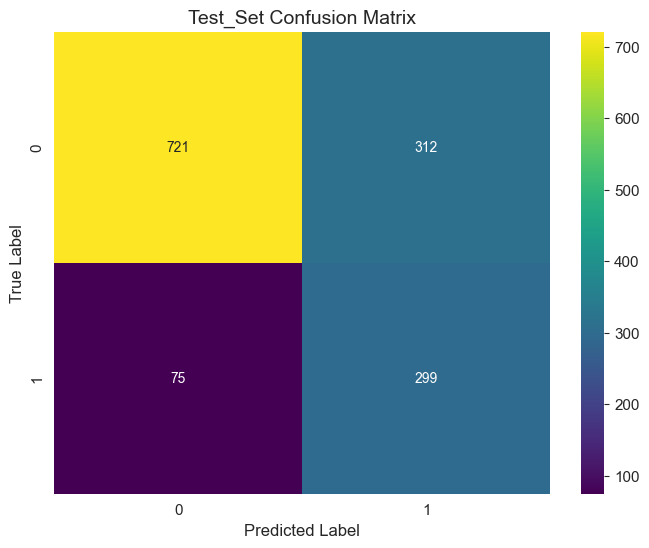

              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.72      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.72      0.74      1407




In [1490]:
logistic_eval_train, logistic_eval_test = eval_metric(logistic, X_train_transformed, y_train, X_test_transformed, y_test)

#### Decision Tree

In [1491]:
tree = DecisionTreeClassifier( max_depth=8,random_state=42).fit(X_train_transformed, y_train)

Train_Set


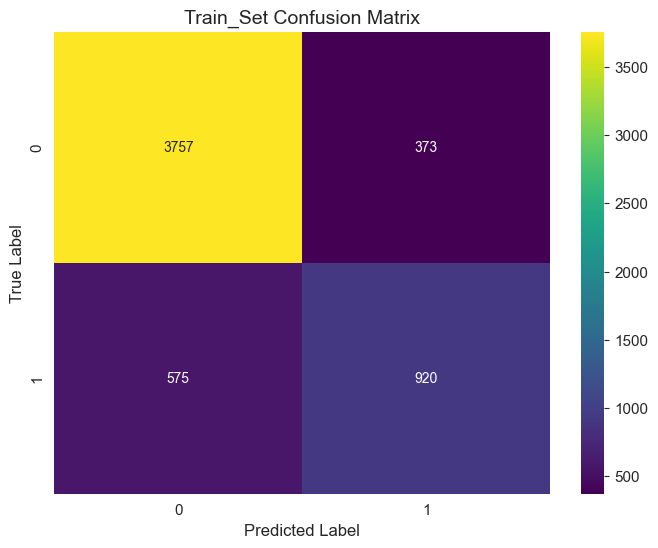

              precision    recall  f1-score   support

           0       0.87      0.91      0.89      4130
           1       0.71      0.62      0.66      1495

    accuracy                           0.83      5625
   macro avg       0.79      0.76      0.77      5625
weighted avg       0.83      0.83      0.83      5625


Test_Set


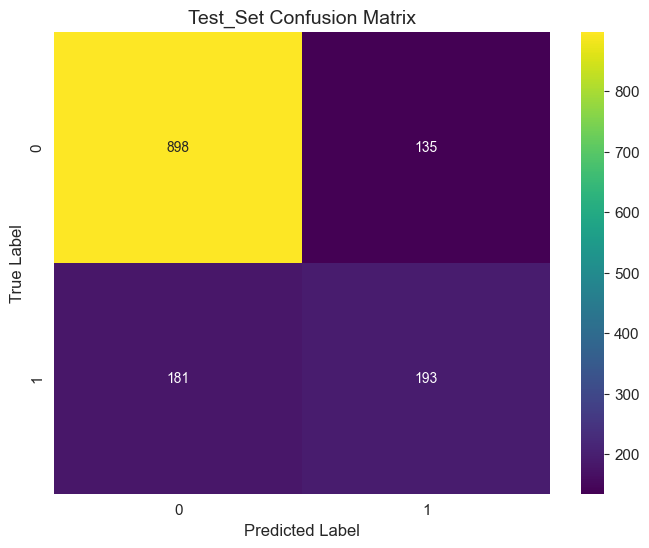

              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1033
           1       0.59      0.52      0.55       374

    accuracy                           0.78      1407
   macro avg       0.71      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407




In [1492]:
tree_eval_train, tree_eval_test = eval_metric(tree, X_train_transformed, y_train, X_test_transformed, y_test)

#### Random Forest

In [1493]:
forest = RandomForestClassifier( max_depth=10,random_state=42).fit(X_train_transformed, y_train)

Train_Set


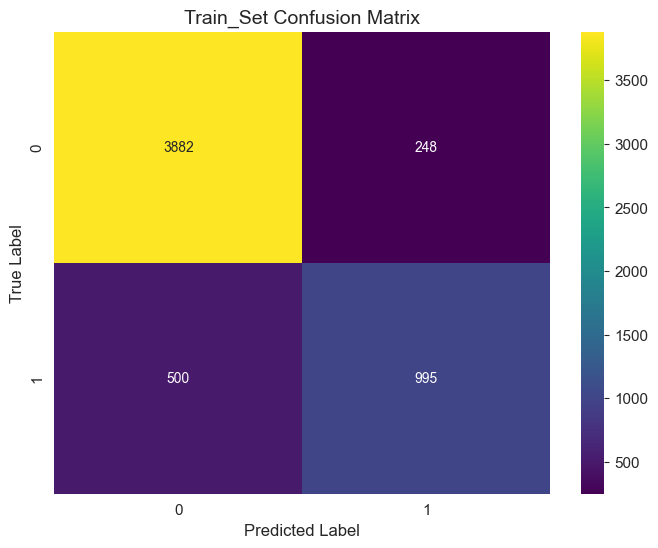

              precision    recall  f1-score   support

           0       0.89      0.94      0.91      4130
           1       0.80      0.67      0.73      1495

    accuracy                           0.87      5625
   macro avg       0.84      0.80      0.82      5625
weighted avg       0.86      0.87      0.86      5625


Test_Set


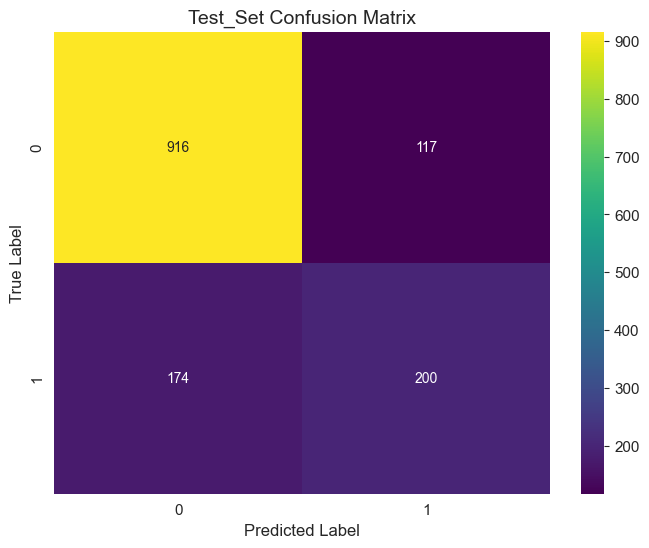

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.53      0.58       374

    accuracy                           0.79      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407




In [1494]:
forest_eval_train, forest_eval_test  = eval_metric(forest, X_train_transformed, y_train, X_test_transformed, y_test)

## K-NEAREST Neighbors (elbow method) 

In [1495]:
def find_best_k(X_train_transformed, y_train, X_test_transformed, y_test, max_k=20, plot=True):
    error_rates = []

    for k in range(1, max_k + 1):
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train_transformed, y_train)
        pred = knn.predict(X_test_transformed)
        error = 1 - accuracy_score(y_test, pred)
        error_rates.append(error)

    best_k = error_rates.index(min(error_rates)) + 1

    if plot:
        plt.figure(figsize=(10,6))
        plt.plot(range(1, max_k + 1), error_rates, color='blue', linestyle='dashed', marker='o',
                 markerfacecolor='red', markersize=8)
        plt.title('Elbow Method - Error Rate vs. K Value')
        plt.xlabel('K')
        plt.ylabel('Error Rate')
        plt.axvline(x=best_k, color='green', linestyle='--', label=f'Best K = {best_k}')
        plt.legend()
        plt.grid(True)
        plt.show()

    return best_k

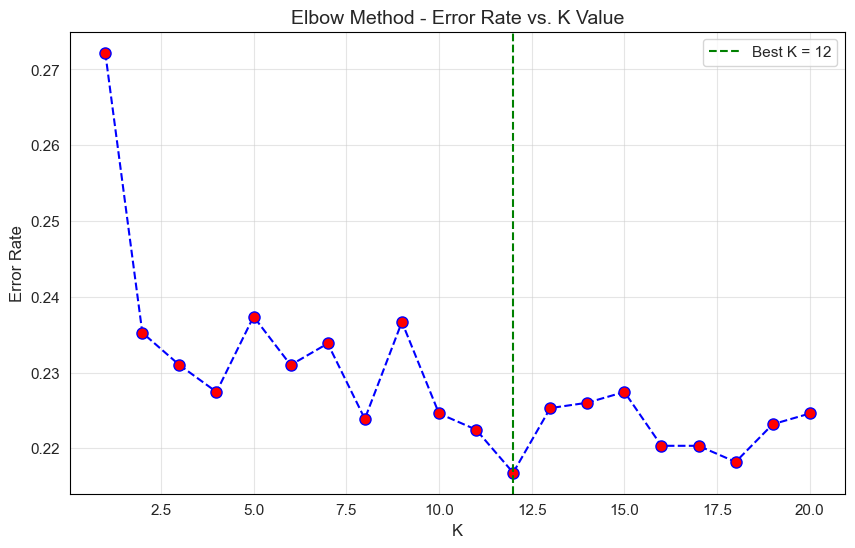

Train_Set


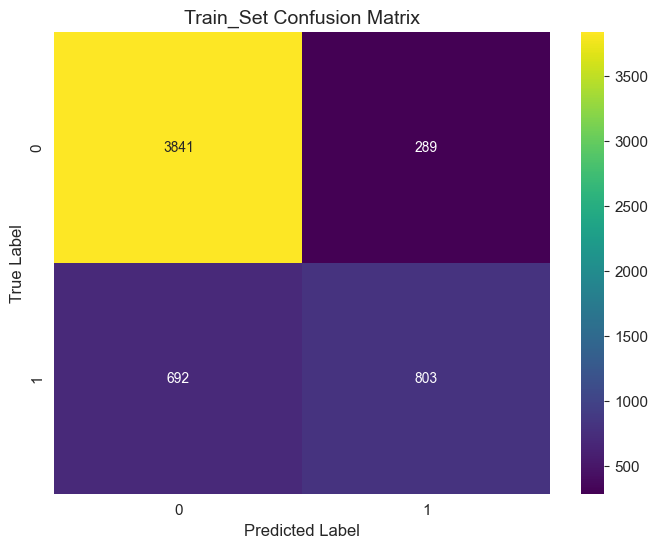

              precision    recall  f1-score   support

           0       0.85      0.93      0.89      4130
           1       0.74      0.54      0.62      1495

    accuracy                           0.83      5625
   macro avg       0.79      0.73      0.75      5625
weighted avg       0.82      0.83      0.82      5625


Test_Set


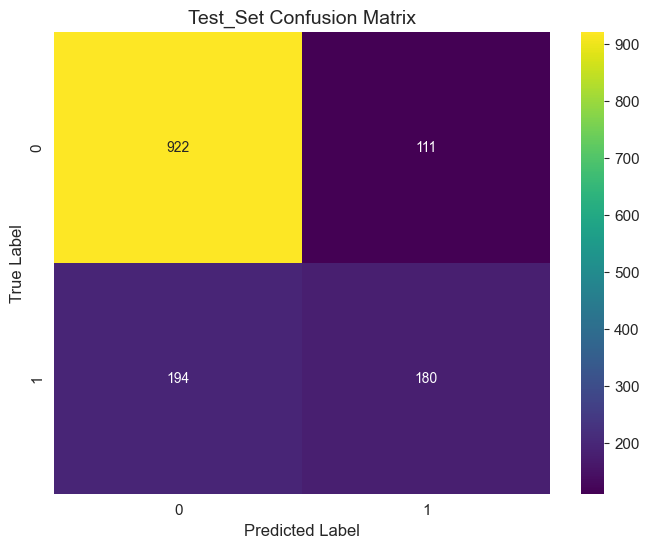

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.48      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407




In [1496]:
best_k = find_best_k(X_train_transformed, y_train, X_test_transformed, y_test)
KNN = KNeighborsClassifier(n_neighbors=best_k).fit(X_train_transformed,y_train)
KNN_eval_train, KNN_eval_test = eval_metric(KNN, X_train_transformed, y_train, X_test_transformed, y_test)

#### <span> XGBoost</span>

In [1497]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

def find_best_n_estimators(X, y, max_depth=2, cv=5, scoring='accuracy'):
    # Define the range of n_estimators to try
    n_estimators_range = range(50, 401, 50)  # You can adjust the range as needed
    param_grid = {'n_estimators': n_estimators_range}
    
    # Create the XGBClassifier with fixed max_depth and other params
    xgb = XGBClassifier(max_depth=max_depth, use_label_encoder=False, eval_metric='logloss')
    
    # Set up GridSearchCV
    grid_search = GridSearchCV(
        estimator=xgb,
        param_grid=param_grid,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )
    
    # Fit grid search
    grid_search.fit(X, y)
    
    # Return the best n_estimators
    print("Best n_estimators:", grid_search.best_params_['n_estimators'])
    print("Best CV score:", grid_search.best_score_)
    return grid_search.best_params_['n_estimators']


Best n_estimators: 50
Best CV score: 0.8039111111111111
Train_Set


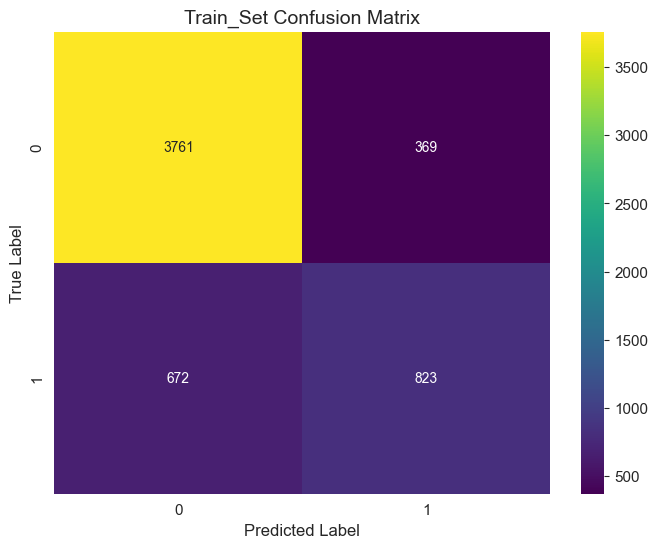

              precision    recall  f1-score   support

           0       0.85      0.91      0.88      4130
           1       0.69      0.55      0.61      1495

    accuracy                           0.81      5625
   macro avg       0.77      0.73      0.75      5625
weighted avg       0.81      0.81      0.81      5625


Test_Set


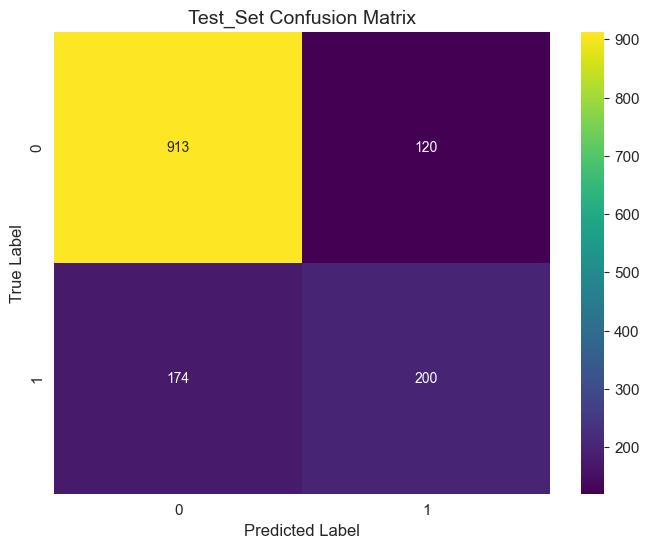

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.62      0.53      0.58       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407




In [1498]:
best_n = find_best_n_estimators(X_train_transformed, y_train, max_depth=2)
xgb = XGBClassifier(n_estimators=best_n, max_depth=2, use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train_transformed, y_train)


xgb_eval_train, xgb_eval_test = eval_metric(xgb, X_train_transformed, y_train, X_test_transformed, y_test)


#### Artificial Neural Network

In [1499]:

nn_model = Sequential(
    [
        Dense(512, activation='relu'),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(1, activation='sigmoid')
    ]
)
nn_model.compile(optimizer='adam', loss=tf.keras.losses.BinaryCrossentropy(from_logits=False), metrics=[tf.keras.metrics.BinaryAccuracy()])

In [1500]:
X_train_tens = tf.convert_to_tensor(X_train_transformed)
y_train_tens = tf.convert_to_tensor(y_train)
nn_model.fit(X_train_tens, y_train_tens, epochs = 50, batch_size=200)

Epoch 1/50
29/29 [==============================] - 1s 5ms/step - loss: 0.4830 - binary_accuracy: 0.7488
Epoch 2/50
29/29 [==============================] - 0s 5ms/step - loss: 0.4260 - binary_accuracy: 0.7929
Epoch 3/50
29/29 [==============================] - 0s 4ms/step - loss: 0.4230 - binary_accuracy: 0.7970
Epoch 4/50
29/29 [==============================] - 0s 5ms/step - loss: 0.4158 - binary_accuracy: 0.8075
Epoch 5/50
29/29 [==============================] - 0s 4ms/step - loss: 0.4099 - binary_accuracy: 0.8044
Epoch 6/50
29/29 [==============================] - 0s 4ms/step - loss: 0.4077 - binary_accuracy: 0.8091
Epoch 7/50
29/29 [==============================] - 0s 5ms/step - loss: 0.4080 - binary_accuracy: 0.8078
Epoch 8/50
29/29 [==============================] - 0s 5ms/step - loss: 0.4052 - binary_accuracy: 0.8092
Epoch 9/50
29/29 [==============================] - 0s 4ms/step - loss: 0.4076 - binary_accuracy: 0.8084
Epoch 10/50
29/29 [==============================] - 0s

44/44 [==============================] - 0s 1ms/step
Train_Set


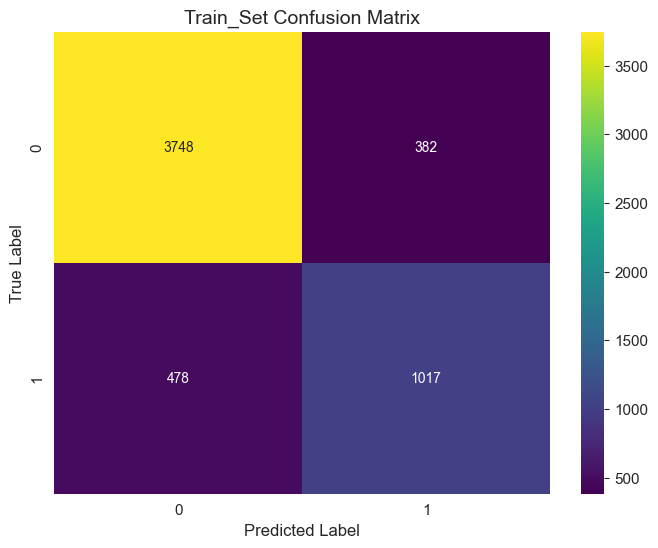

              precision    recall  f1-score   support

           0       0.89      0.91      0.90      4130
           1       0.73      0.68      0.70      1495

    accuracy                           0.85      5625
   macro avg       0.81      0.79      0.80      5625
weighted avg       0.84      0.85      0.85      5625


Test_Set


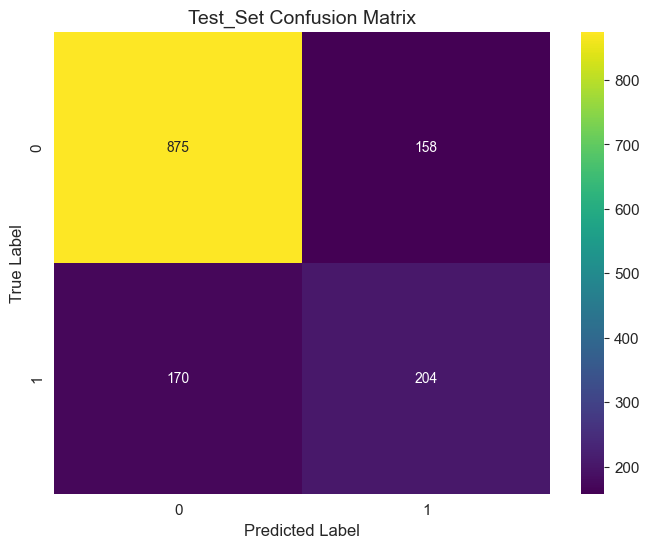

              precision    recall  f1-score   support

           0       0.84      0.85      0.84      1033
           1       0.56      0.55      0.55       374

    accuracy                           0.77      1407
   macro avg       0.70      0.70      0.70      1407
weighted avg       0.76      0.77      0.77      1407




In [1501]:
nn_model_eval_train, nn_model_eval_test = eval_metric(nn_model, X_train_transformed, y_train, X_test_transformed, y_test)

Train_Set


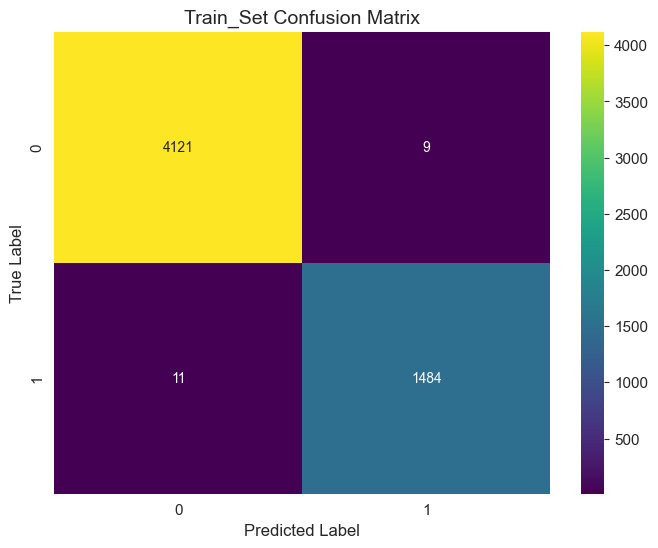

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4130
           1       0.99      0.99      0.99      1495

    accuracy                           1.00      5625
   macro avg       1.00      1.00      1.00      5625
weighted avg       1.00      1.00      1.00      5625


Test_Set


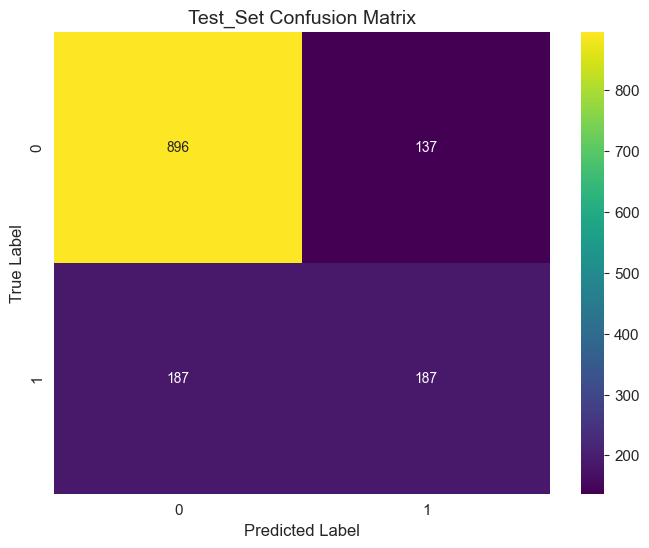

              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1033
           1       0.58      0.50      0.54       374

    accuracy                           0.77      1407
   macro avg       0.70      0.68      0.69      1407
weighted avg       0.76      0.77      0.76      1407


Bagging Model Train Eval: {'0': {'precision': 0.9973378509196515, 'recall': 0.997820823244552, 'f1-score': 0.9975792786250303, 'support': 4130.0}, '1': {'precision': 0.9939718687206965, 'recall': 0.9926421404682274, 'f1-score': 0.9933065595716198, 'support': 1495.0}, 'accuracy': 0.9964444444444445, 'macro avg': {'precision': 0.995654859820174, 'recall': 0.9952314818563897, 'f1-score': 0.995442919098325, 'support': 5625.0}, 'weighted avg': {'precision': 0.9964432476507737, 'recall': 0.9964444444444445, 'f1-score': 0.9964436848499459, 'support': 5625.0}}
Bagging Model Test Eval: {'0': {'precision': 0.827331486611265, 'recall': 0.8673765730880929, 'f1-score': 0.84688

In [1502]:
from sklearn.ensemble import BaggingClassifier

# Instantiate the BaggingClassifier (default base_estimator is DecisionTreeClassifier)
bagging_model = BaggingClassifier(
    n_estimators=100,        # Number of base estimators
    random_state=42,
    n_jobs=-1
)

# Fit the bagging model on your transformed training data
bagging_model.fit(X_train_transformed, y_train)

# Evaluate the model using your eval_metric function
bagging_eval_train, bagging_eval_test = eval_metric(
    bagging_model, X_train_transformed, y_train, X_test_transformed, y_test
)

print("Bagging Model Train Eval:", bagging_eval_train)
print("Bagging Model Test Eval:", bagging_eval_test)

Voting Ensemble Technique

In [1503]:

knn = KNeighborsClassifier(n_neighbors=best_k)
xgb = XGBClassifier(n_estimators=100, max_depth=2, use_label_encoder=False, eval_metric='logloss')
forest = RandomForestClassifier(max_depth=10, random_state=42)
tree = DecisionTreeClassifier(random_state=42)

voting_model = VotingClassifier(
    estimators=[
        ('knn', knn),
        ('xgb', xgb),
        ('forest', forest),
        ('tree', tree)
    ],
    voting='soft',  # or 'hard' if you prefer majority vote
    n_jobs=-1
)


Train_Set


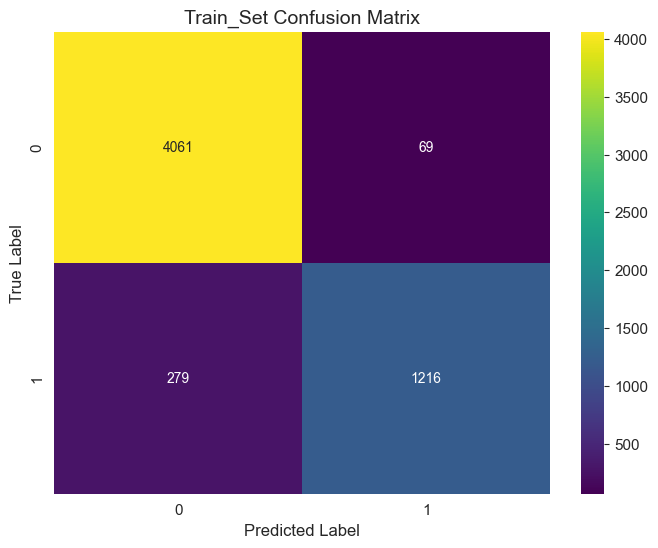

              precision    recall  f1-score   support

           0       0.94      0.98      0.96      4130
           1       0.95      0.81      0.87      1495

    accuracy                           0.94      5625
   macro avg       0.94      0.90      0.92      5625
weighted avg       0.94      0.94      0.94      5625


Test_Set


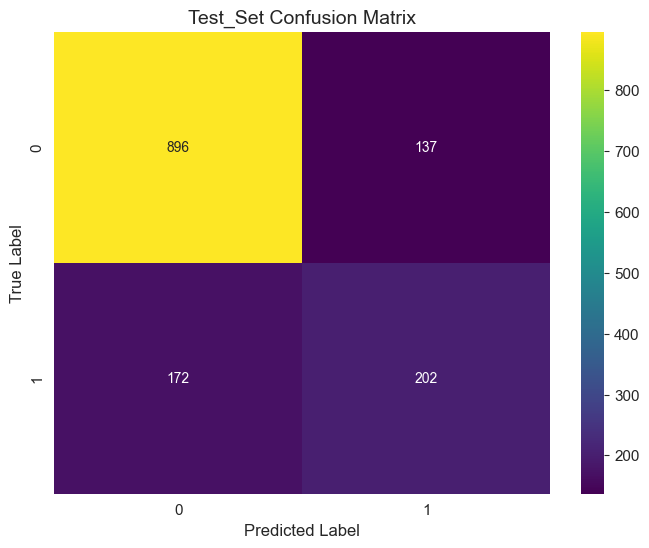

              precision    recall  f1-score   support

           0       0.84      0.87      0.85      1033
           1       0.60      0.54      0.57       374

    accuracy                           0.78      1407
   macro avg       0.72      0.70      0.71      1407
weighted avg       0.77      0.78      0.78      1407


Voting Model Train Eval: {'0': {'precision': 0.9357142857142857, 'recall': 0.9832929782082325, 'f1-score': 0.958913813459268, 'support': 4130.0}, '1': {'precision': 0.9463035019455253, 'recall': 0.8133779264214047, 'f1-score': 0.874820143884892, 'support': 1495.0}, 'accuracy': 0.9381333333333334, 'macro avg': {'precision': 0.9410088938299055, 'recall': 0.8983354523148186, 'f1-score': 0.91686697867208, 'support': 5625.0}, 'weighted avg': {'precision': 0.9385286640726329, 'recall': 0.9381333333333334, 'f1-score': 0.9365635848346117, 'support': 5625.0}}
Voting Model Test Eval: {'0': {'precision': 0.8389513108614233, 'recall': 0.8673765730880929, 'f1-score': 0.8529271

In [1504]:
voting_model.fit(X_train_transformed, y_train)

voting_eval_train, voting_eval_test = eval_metric(
    voting_model, X_train_transformed, y_train, X_test_transformed, y_test
)

print("Voting Model Train Eval:", voting_eval_train)
print("Voting Model Test Eval:", voting_eval_test)

Stacking Ensemble Technique

In [1505]:
knn = KNeighborsClassifier(n_neighbors=best_k)
xgb = XGBClassifier(n_estimators=100, max_depth=2, use_label_encoder=False, eval_metric='logloss')
forest = RandomForestClassifier(max_depth=10, random_state=42)
tree = DecisionTreeClassifier(random_state=42)

stacked_model = StackingClassifier(
    estimators=[
        ('knn', knn),
        ('xgb', xgb),
        ('forest', forest),
        ('tree', tree)
    ],
    final_estimator=LogisticRegression(),
    n_jobs=-1,
    cv=5
)

Train_Set


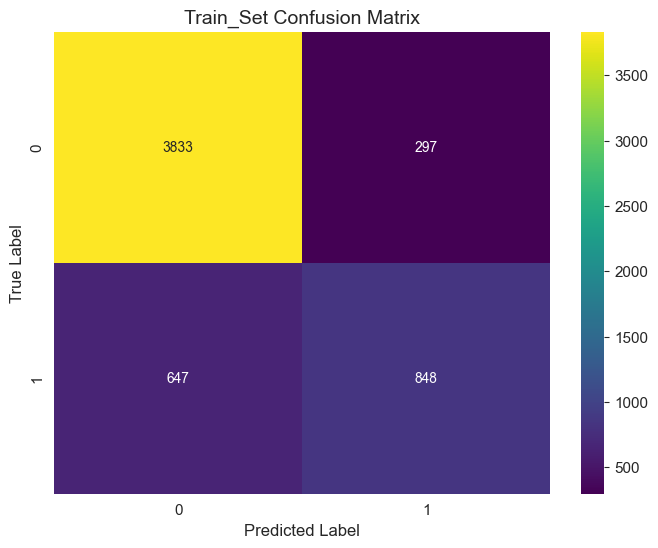

              precision    recall  f1-score   support

           0       0.86      0.93      0.89      4130
           1       0.74      0.57      0.64      1495

    accuracy                           0.83      5625
   macro avg       0.80      0.75      0.77      5625
weighted avg       0.83      0.83      0.82      5625


Test_Set


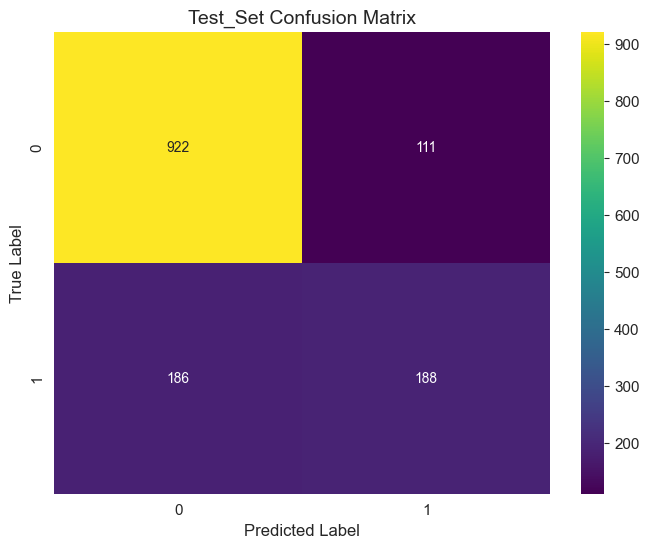

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407


Stacked Model Train Eval: {'0': {'precision': 0.8555803571428572, 'recall': 0.9280871670702179, 'f1-score': 0.8903600464576075, 'support': 4130.0}, '1': {'precision': 0.7406113537117904, 'recall': 0.5672240802675586, 'f1-score': 0.6424242424242425, 'support': 1495.0}, 'accuracy': 0.8321777777777778, 'macro avg': {'precision': 0.7980958554273239, 'recall': 0.7476556236688883, 'f1-score': 0.766392144440925, 'support': 5625.0}, 'weighted avg': {'precision': 0.8250241508976225, 'recall': 0.8321777777777778, 'f1-score': 0.8244642194300732, 'support': 5625.0}}
Stacked Model Test Eval: {'0': {'precision': 0.8321299638989169, 'recall': 0.8925459825750242, 'f1-score': 0.86

In [1506]:
stacked_model.fit(X_train_transformed, y_train)

stacked_eval_train, stacked_eval_test = eval_metric(
    stacked_model, X_train_transformed, y_train, X_test_transformed, y_test
)

print("Stacked Model Train Eval:", stacked_eval_train)
print("Stacked Model Test Eval:", stacked_eval_test)


### Comparing Models

8
8


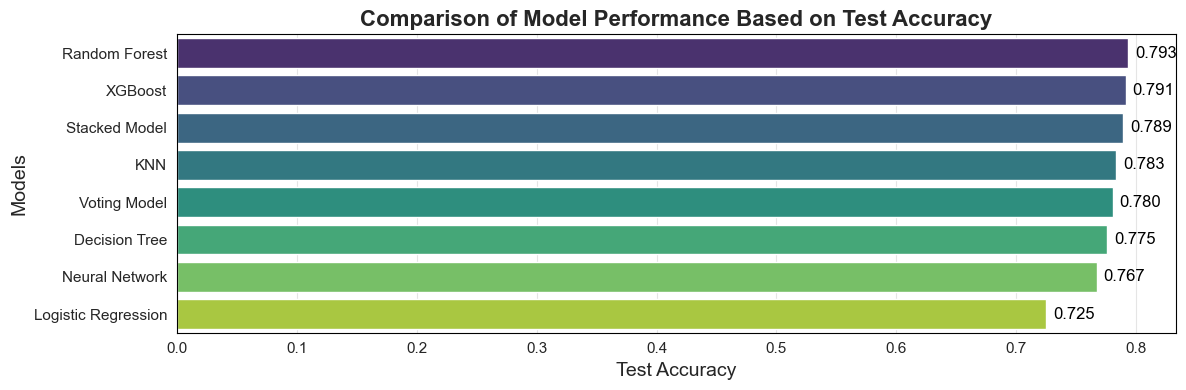

In [1507]:
print(len([
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "XGBoost",
    "Neural Network",
    "KNN",
    "Stacked Model",
    "Voting Model",   # Add this if you have 8 accuracy values
    # "Bagging Model", # Add if you have 9 accuracy values
]))

print(len([
    logistic_eval_test['accuracy'],
    tree_eval_test['accuracy'],
    forest_eval_test['accuracy'],
    xgb_eval_test['accuracy'],
    nn_model_eval_test['accuracy'],
    KNN_eval_test['accuracy'],
    stacked_eval_test['accuracy'],
    voting_eval_test['accuracy'],
    # bagging_eval_test['accuracy'],
]))

compare = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "Neural Network",
        "KNN",
        "Stacked Model",
        "Voting Model"   # Adde
    ],
    "Accuracy": [
        logistic_eval_test['accuracy'],
        tree_eval_test['accuracy'],
        forest_eval_test['accuracy'],
        xgb_eval_test['accuracy'],
        nn_model_eval_test['accuracy'],
        KNN_eval_test['accuracy'],
        stacked_eval_test['accuracy'],
        voting_eval_test['accuracy']
    ]
})

compare = compare.sort_values(by="Accuracy", ascending=False)

plt.figure(figsize=(12, 4))
ax = sns.barplot(x="Accuracy", y="Model", data=compare, palette="viridis")

for p in ax.patches:
    ax.annotate(f"{p.get_width():.3f}", 
                (p.get_x() + p.get_width(), p.get_y() + p.get_height()/2), 
                xytext=(5, 0), textcoords='offset points', ha="left", va="center", size=12, color='black')

plt.title("Comparison of Model Performance Based on Test Accuracy", size=16, weight='bold')
plt.xlabel('Test Accuracy', size=14)
plt.ylabel('Models', size=14)

plt.tight_layout()
plt.show()



### Final Model

In [1508]:
import pickle
final_model=forest

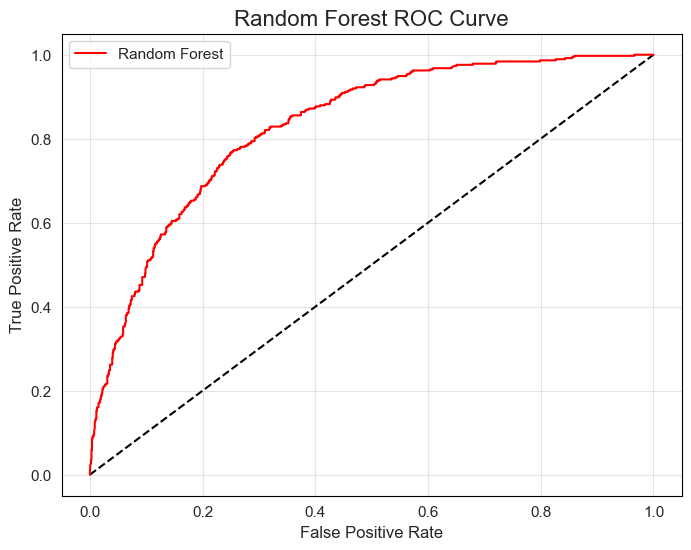

In [1509]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# Create and fit the Random Forest model first
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train_transformed, y_train)  # This is essential - train the model first

# Now create the ROC curve using the fitted model
fpr_rf, tpr_rf, thresholds = roc_curve(y_test, rf.predict_proba(X_test_transformed)[:, 1])

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal reference line
plt.plot(fpr_rf, tpr_rf, label='Random Forest', color="r")
plt.legend()
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve', fontsize=16)
plt.show()


In [1510]:
pickle.dump(final_model, open("model.pkl", "wb"))
pickle.dump(preprocessor, open("preprocessor.pkl", "wb"))